## Kaggle Competition: The Gemma4 Good Hackathon
Your mission is to create a solution that addresses a real-world challenge using Gemma 4 models, whether that’s an application that helps millions or a specialized model that could exponentially scale innovation.

#### Link <https://www.kaggle.com/competitions/gemma-4-good-hackathon/overview>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)



import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))



# 📱 Gemma 4 E2B-it Mobile Simulation Notebook (iPad Optimized)
**Model**: google/gemma-4-E2B-it (Edge / Mobile optimized)

**Purpose**: Simulate real mobile AI app experience on iPad  
**Theme**: HK City Personal Finance Assistant (bills, receipts, MPF, rental, tax)

**How to use on iPad**:
1. Run all cells
2. Click the public Gradio URL
3. Open the link in Safari → feels like a native mobile app

In [2]:
# !pip install git+https://github.com/huggingface/transformers.git 

In [3]:
# !pip install -q accelerate gradio pillow --quiet

In [4]:
# !pip install -q aiohttp nest_asyncio --quiet

In [5]:
# !pip install -q opencv-python-headless --quiet

In [6]:
# import torch
# from transformers import AutoProcessor, AutoModelForCausalLM
# from PIL import Image
# import gradio as gr
# import time
# print("✅ Packages ready for mobile simulation")


import cv2
import numpy as np

import torch
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image
import gradio as gr
import time
import torchaudio
import soundfile as sf
import json
from io import BytesIO
from IPython.display import display, Markdown

import aiohttp
import asyncio
import nest_asyncio
from io import BytesIO
from PIL import Image

# Enable async in Jupyter/Kaggle notebook
nest_asyncio.apply()

print("✅ Dependencies installed")

/media/johnsonhk88/Big-Data-Disk7/venv-gemma4/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Dependencies installed


### Load Gemma 4 E2B-it

In [7]:
MODEL_ID1 = "google/gemma-4-E4B-it"
MODEL_ID2 = "google/gemma-4-E2B-it"

Sel_Model = MODEL_ID1

print(f"Loading Gemma 4 {Sel_Model}... (this may take 1-2 minutes)")
processor = AutoProcessor.from_pretrained(Sel_Model, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    Sel_Model,
    device_map="auto",
    dtype=torch.bfloat16,
    trust_remote_code=True
)
print(f"✅ Gemma 4 {Sel_Model} loaded successfully on {model.device}")

Loading Gemma 4 google/gemma-4-E4B-it... (this may take 1-2 minutes)


KeyboardInterrupt: 

### Cell 3: Unified Generation Helper

In [8]:
def gemma_run(messages, max_new_tokens=1024, temperature=0.7):
    start = time.time()

    # === FIX: Extract all images from messages ===
    images = []
    for msg in messages:
        if isinstance(msg.get("content"), list):
            for part in msg["content"]:
                if part.get("type") == "image" and "image" in part:
                    images.append(part["image"])

    
    # FIXED: apply_chat_template returns string → then processor(text=...)
    prompt = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False
    )
    
    print(f"Prompt: {prompt}")
    
    # === FIX: Pass images= explicitly ===
    inputs = processor(
        text=prompt,
        images=images if images else None,
        return_tensors="pt",
        padding=True
    ).to(model.device)
    
    input_len = inputs["input_ids"].shape[-1]
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        do_sample=True,
        top_p=0.95
    )
    
    response = processor.decode(outputs[0][input_len:], skip_special_tokens=True)
    latency = round(time.time() - start, 2)
    return response, latency

### Text Chat + Reasoning + Thinking Mode

In [8]:
%%time
messages = [
    {"role": "system", "content": "You are a helpful assistant. Use thinking mode when needed."},
    {"role": "user", "content": "Think step by step: A person in Hong Kong earns HK$45,000/month. How can they maximize tax savings in 2026 with MPF voluntary contributions and self-education expenses?"}
]

response, latency = gemma_run(messages)
print("=== Text + Thinking Test ===\n")
print(response)
print(f"\n⏱️ Latency: {latency}s")

Prompt: <bos><|turn>system
You are a helpful assistant. Use thinking mode when needed.<turn|>
<|turn>user
Think step by step: A person in Hong Kong earns HK$45,000/month. How can they maximize tax savings in 2026 with MPF voluntary contributions and self-education expenses?<turn|>
<|turn>model

=== Text + Thinking Test ===

thought
Here's a thinking process to construct the advice:

1.  **Analyze the Request:**
    *   **Goal:** Maximize tax savings in 2026.
    *   **Income:** HKD $45,000 per month (Annual income: $540,000).
    *   **Tools:** MPF Voluntary Contributions (VCS) and Self-Education Expenses.
    *   **Location:** Hong Kong (Crucial for tax rules).

2.  **Identify Key Hong Kong Tax Principles (Crucial Context Check):**
    *   Hong Kong has a territorial tax system. Income is generally taxed based on its source in HK.
    *   Tax rates are progressive.
    *   Deductions are key to reducing the taxable income.
    *   *Self-Correction/Refinement:* While the prompt asks ab

In [63]:
Markdown(response)

thought
Here's a thinking process to construct the advice:

1.  **Analyze the Request:**
    *   **Goal:** Maximize tax savings.
    *   **Location:** Hong Kong.
    *   **Income:** HK$45,000/month (HK$540,000 annually).
    *   **Tools:** MPF Voluntary Contributions and Self-Education Expenses.
    *   **Timeframe:** 2026.

2.  **Understand Hong Kong Tax Basics (Crucial Step):**
    *   *Key Fact:* Hong Kong has a territorial tax system. Income is generally only taxed if it's sourced in Hong Kong.
    *   *Personal Tax:* The basic rate of income tax in Hong Kong is relatively low compared to many other jurisdictions, and the tax liability depends heavily on *taxable income* after deductions and allowances.
    *   *Deductions:* The primary mechanisms for tax reduction are:
        *   Personal Allowances (Standard deductions).
        *   Specific tax reliefs (e.g., MPF, education).

3.  **Analyze the Tools for Tax Savings:**

    *   **MPF Voluntary Contributions (MPF VC):**
        *   *Mechanism:* Contributions made above the mandatory employer/employee contributions can often be claimed as a tax deduction (subject to limits).
        *   *Goal:* Maximize the contribution up to the allowable limit to reduce assessable income.
    *   **Self-Education Expenses:**
        *   *Mechanism:* Certain expenses related to furthering one's education can be claimed as a deduction.
        *   *Goal:* Ensure all qualifying expenses are documented and claimed.

4.  **Determine the Strategy (Step-by-Step Plan):**

    *   **Step 1: Calculate Current Tax Situation (Baseline):** Estimate the current tax liability to see how much saving is possible. (Since I don't have the full tax code for 2026, I must use general principles and advise checking the official Inland Revenue Department (IRD) guidelines.)
    *   **Step 2: Maximize MPF VC:** Determine the maximum allowable contribution limit for tax deduction purposes in Hong Kong (this is a critical, changing piece of information that needs a disclaimer).
    *   **Step 3: Optimize Education Expenses:** Define *what* qualifies as a deductible education expense (e.g., specific courses, certifications).
    *   **Step 4: Integration & Planning:** Advise on the timing and documentation needed for 2026 filing.

5.  **Refining the Advice & Adding Caveats (Self-Correction/Review):**

    *   *Disclaimer:* I am an AI, not a licensed tax agent in Hong Kong. Tax laws change. This is general advice.
    *   *2026 Specificity:* Since 2026 laws are not finalized, the advice must be based on current/expected regulations and emphasize consulting a local professional.
    *   *MPF Limits:* The tax deductibility of MPF contributions is capped. The person must know this cap.

6.  **Structuring the Output:** (Use clear headings, bullet points, and a strong disclaimer.) (This leads directly to the final generated response.)This is a complex financial planning question because tax laws, especially specific deduction limits, can change annually. **It is crucial to state upfront that I am an AI and not a licensed tax advisor in Hong Kong. Tax regulations for 2026 are not yet finalized, so this advice is based on current best practices and general Hong Kong tax principles. The individual MUST consult a qualified Hong Kong tax agent or accountant before making any decisions.**

That said, here is a step-by-step strategy to maximize tax savings using MPF voluntary contributions and education expenses in Hong Kong.

---

## 🇭🇰 Hong Kong Tax Context Overview

Hong Kong operates a territorial tax system. For most residents, the tax savings come from reducing their **Assessable Income** through allowable deductions and reliefs. The goal is to push as much eligible spending as possible into tax-deductible categories.

## Step 1: Analyze the Income and Tax Baseline

*   **Annual Income:** HK$45,000/month $\times$ 12 months = **HK$540,000 per year.**
*   **Baseline Action:** Before adding deductions, the person must ensure they are utilizing all standard personal allowances and reliefs available to them for 2026.

## Step 2: Maximizing MPF Voluntary Contributions (The Major Lever)

MPF Voluntary Contributions are often the most direct and largest tool for income tax reduction, provided the contribution is within the limits set by the Inland Revenue Department (IRD).

**Action Plan:**

### Image Analysis

In [12]:
# Upload your image first (bill, receipt, photo) via "Add Data" or Kaggle input
# Example path (change to your uploaded file)
# image = Image.open("/kaggle/input/your-image/example-bill.jpg").convert("RGB")
#
img_url1 = "https://picsum.photos/id/237/200/300"
img_url2 = "https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/Demos/sample-data/GoldenGate.png"

In [15]:
# Helper to load image from URL
async def load_image_from_url_async(url: str) -> Image.Image:
    """Download image using aiohttp (async)"""
    async with aiohttp.ClientSession() as session:
        async with session.get(url, timeout=120) as resp:
            resp.raise_for_status()
            data = await resp.read()
            return Image.open(BytesIO(data)).convert("RGB")

# Sync wrapper so you can call it easily in normal cells
def load_image_from_url(url: str) -> Image.Image:
    return asyncio.run(load_image_from_url_async(url))

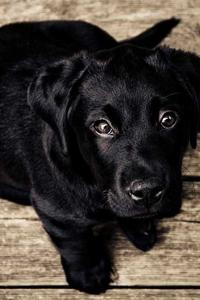

In [16]:
image =  load_image_from_url(img_url1)
image

In [17]:
messages1 = [
    # {"role": "system", "content": "You are a document analyst."},
    {
        "role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "What is shown in this image?"}
        ]
    }
]

In [18]:
messages1

[{'role': 'user',
  'content': [{'type': 'image',
    'image': <PIL.Image.Image image mode=RGB size=200x300>},
   {'type': 'text', 'text': 'What is shown in this image?'}]}]

In [21]:
%%time
response, latency = gemma_run(messages1)   # Note: for multimodal, we will improve in next version if needed
print("=== Image Analysis Test ===\n")
print(response)
print(f"\n⏱️ Latency: {latency}s")
Markdown(response)

Prompt: <bos><|turn>user
<|image|>What is shown in this image?<turn|>
<|turn>model

=== Image Analysis Test ===

The image shows a **black Labrador puppy** lying down on a **wooden surface**.

The puppy is looking directly towards the viewer, and its coat appears sleek and black. The wooden surface has a rustic or weathered texture.

⏱️ Latency: 6.93s
CPU times: user 7 s, sys: 31.1 ms, total: 7.03 s
Wall time: 6.93 s


The image shows a **black Labrador puppy** lying down on a **wooden surface**.

The puppy is looking directly towards the viewer, and its coat appears sleek and black. The wooden surface has a rustic or weathered texture.

## 3. Video Analysis (via multiple frames)

In [22]:
async def download_video_async(url: str, save_path: str = "temp_video.mp4"):
    async with aiohttp.ClientSession() as session:
        async with session.get(url, timeout=30) as resp:
            resp.raise_for_status()
            with open(save_path, "wb") as f:
                while True:
                    chunk = await resp.content.read(8192)
                    if not chunk:
                        break
                    f.write(chunk)
    return save_path

In [25]:
# ==================== CHANGE THIS URL ====================
video_url = "https://raw.githubusercontent.com/johnsonhk88/voice-over-video-sample1/main/9_16_video/1.mp4"

print("Downloading video with aiohttp...")
video_path = await download_video_async(video_url)
print("✅ Video downloaded")

✅ Video downloaded


In [31]:
# Extract 6 frames using OpenCV
cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_indices = [int(i * total_frames / 7) for i in range(1, 7)]

In [32]:
total_frames

192

In [33]:
cap

< cv2.VideoCapture 0x7fbbb5e80ab0>